In [1]:
# Ativa o autoreload para atualizar as funções em tempo real
%load_ext autoreload
%autoreload 2

import sys
import os

raiz_do_projeto = os.path.abspath(os.path.join('..'))
caminho_backend = os.path.join(raiz_do_projeto, 'backend')

if caminho_backend not in sys.path:
    sys.path.append(caminho_backend)

from app.services.feature_extractor import extract_features

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

caminho_modelos = os.path.join(raiz_do_projeto, 'ml_pipeline')

CONFIG_MODELS = {
    # Supervisionados - Árvore de Decisão
    "arvore_base":      ("arvore-de-decisao/dt_base_final.pkl",    "df_35", "estimator"),
    "arvore_otimizado": ("arvore-de-decisao/dt_results_final.pkl", "df_35", "best_estimator"),

    # Supervisionados - XGBoost  
    "xgboost_base":      ("xgboost/xgb_base_final.pkl",    "df_35", "estimator"),
    "xgboost_otimizado": ("xgboost/xgb_results_final.pkl", "df_35", "best_estimator"),

    # Nao-supervisionados (pipeline: scaler -> pca -> modelo)
    "kmeans":            ("nao-supervisionados/kmeans_35.pkl", None, None),
    "isolation_forest":  ("nao-supervisionados/isolation_forest_35.pkl", None, None),
}


In [2]:
models = {
    k: joblib.load(os.path.join(caminho_modelos, v[0])) for k, v in CONFIG_MODELS.items()
}

models_df_35 = {
    k: (v[CONFIG_MODELS[k][1]][CONFIG_MODELS[k][2]] if CONFIG_MODELS[k][1] is not None else v)
    for k, v in models.items()
}

c:\Users\Client\Desktop\Projetos LeoBardo\trabalho-ufrj-iml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Client\AppData\Local\Programs\Python\Python314\Lib\pickle.py:1829: UserWarning: [21:32:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between

In [3]:
import pandas as pd

In [5]:
df = pd.read_csv('../data/LLM_URLS.csv')
df.head()

,URL,Label
0,http://192.168.0.1/secure/login.php,1
1,https://www.paypaI.com/signin,1
2,http://secure-update.apple.com.login-verify-ac...,1
3,https://bank-of-america-secure-login.com,1
4,https://crypto-wallet-verify.net/seed,1


In [6]:
display(df['URL'])

0                    http://192.168.0.1/secure/login.php
1                          https://www.paypaI.com/signin
2      http://secure-update.apple.com.login-verify-ac...
3               https://bank-of-america-secure-login.com
4                  https://crypto-wallet-verify.net/seed
                             ...                        
343    http://salesforce-login-unauthorized.info/acce...
344                            https://www.stanford.edu/
345    http://zendesk-support-ticket-closed.xyz/reope...
346                             https://www.harvard.edu/
347    http://freshdesk-customer-reply.net/waiting?ti...
Name: URL, Length: 348, dtype: str

In [7]:
extracted_feats = {url: extract_features(url) for url in df['URL']}

In [ ]:
extracted_feats

{'http://192.168.0.1/secure/login.php': {'URLLength': 35,
  'DomainLength': 11,
  'IsDomainIP': 1,
  'IsHTTPS': 0,
  'NoOfSubDomain': 0,
  'NoOfLettersInURL': 14,
  'LetterRatioInURL': 0.4,
  'NoOfDegitsInURL': 8,
  'DegitRatioInURL': 0.22857142857142856,
  'NoOfOtherSpecialCharsInURL': 6,
  'SpacialCharRatioInURL': 0.17142857142857143,
  'HasObfuscation': 0,
  'NoOfObfuscatedChar': 0,
  'ObfuscationRatio': 0.0,
  'CharContinuationRate': 0.05714285714285714,
  'URLCharProb': 0.8244824310018041,
  'NoOfDots': 4,
  'NoOfHyphens': 0,
  'NoOfUnderline': 0,
  'NoOfSlash': 4,
  'NoOfQMarkInURL': 0,
  'NoOfEqual': 0,
  'NoOfAtInURL': 0,
  'NoOfDollarInURL': 0,
  'NoOfExclamationInURL': 0,
  'NoOfHashInURL': 0,
  'NoOfPercentInURL': 0,
  'NoOfAmpersandInURL': 0,
  'Bank': 0,
  'Pay': 0,
  'Crypto': 0,
  'LineOfCode': 0,
  'LargestLineLength': 0,
  'HasTitle': 0,
  'DomainTitleMatchScore': 0.0,
  'URLTitleMatchScore': 0.0,
  'HasFavicon': 0,
  'Robots': 0,
  'IsResponsive': 0,
  'NoOfURLRedirec

In [8]:
extracted_feats.values()

dict_values([{'URLLength': 35, 'DomainLength': 11, 'IsDomainIP': 1, 'IsHTTPS': 0, 'NoOfSubDomain': 0, 'NoOfLettersInURL': 14, 'LetterRatioInURL': 0.4, 'NoOfDegitsInURL': 8, 'DegitRatioInURL': 0.22857142857142856, 'NoOfOtherSpecialCharsInURL': 6, 'SpacialCharRatioInURL': 0.17142857142857143, 'HasObfuscation': 0, 'NoOfObfuscatedChar': 0, 'ObfuscationRatio': 0.0, 'CharContinuationRate': 0.05714285714285714, 'URLCharProb': 0.8244824310018041, 'NoOfDots': 4, 'NoOfHyphens': 0, 'NoOfUnderline': 0, 'NoOfSlash': 4, 'NoOfQMarkInURL': 0, 'NoOfEqual': 0, 'NoOfAtInURL': 0, 'NoOfDollarInURL': 0, 'NoOfExclamationInURL': 0, 'NoOfHashInURL': 0, 'NoOfPercentInURL': 0, 'NoOfAmpersandInURL': 0, 'Bank': 0, 'Pay': 0, 'Crypto': 0, 'LineOfCode': 0, 'LargestLineLength': 0, 'HasTitle': 0, 'DomainTitleMatchScore': 0.0, 'URLTitleMatchScore': 0.0, 'HasFavicon': 0, 'Robots': 0, 'IsResponsive': 0, 'NoOfURLRedirect': 0, 'NoOfSelfRedirect': 0, 'HasDescription': 0, 'NoOfPopup': 0, 'NoOfiFrame': 0, 'HasExternalFormSubmi

In [9]:
df_feats = pd.DataFrame.from_dict(extracted_feats, orient='index')

colunas_do_treinamento = ['URLLength', 'DomainLength', 'CharContinuationRate', 'NoOfLettersInURL',
       'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
       'NoOfQMarkInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL',
       'IsHTTPS', 'LargestLineLength', 'HasTitle', 'HasFavicon', 'Robots',
       'IsResponsive', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSubmitButton', 'HasHiddenFields',
       'HasPasswordField', 'Bank', 'Pay', 'NoOfEmptyRef']

df_dados = df_feats[colunas_do_treinamento]
previsoes = models_df_35['arvore_base'].predict(df_dados)
previsoes_corrigidas = 1 - previsoes
df_dados['Previsao_Modelo'] = previsoes_corrigidas
df_dados['URL'] = df_dados.index
df_final = pd.merge(df, df_dados[['URL', 'Previsao_Modelo']], on='URL', how='left')

              precision    recall  f1-score   support

Legítima (0)     1.0000    0.6149    0.7616       174
Phishing (1)     0.7220    1.0000    0.8386       174

    accuracy                         0.8075       348
   macro avg     0.8610    0.8075    0.8001       348
weighted avg     0.8610    0.8075    0.8001       348



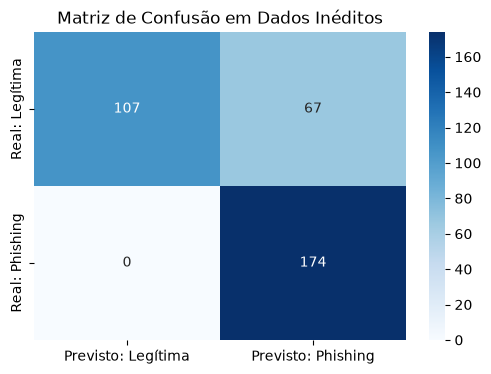

In [10]:
y_verdadeiro = df_final['Label']
y_previsto = df_final['Previsao_Modelo']

print(classification_report(
    y_verdadeiro, 
    y_previsto, 
    target_names=['Legítima (0)', 'Phishing (1)'],
    digits=4
))

matriz = confusion_matrix(y_verdadeiro, y_previsto)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: Legítima', 'Previsto: Phishing'],
            yticklabels=['Real: Legítima', 'Real: Phishing'])
plt.title('Matriz de Confusão em Dados Inéditos')
plt.show()

              precision    recall  f1-score   support

Legítima (0)     1.0000    0.7126    0.8322       174
Phishing (1)     0.7768    1.0000    0.8744       174

    accuracy                         0.8563       348
   macro avg     0.8884    0.8563    0.8533       348
weighted avg     0.8884    0.8563    0.8533       348



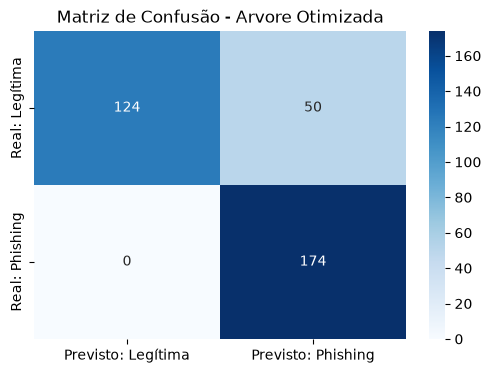

In [13]:
df_dados = df_feats[colunas_do_treinamento]
previsoes = models_df_35['arvore_otimizado'].predict(df_dados)
previsoes_corrigidas = 1 - previsoes
df_dados['Previsao_Modelo'] = previsoes_corrigidas
df_dados['URL'] = df_dados.index
df_final = pd.merge(df, df_dados[['URL', 'Previsao_Modelo']], on='URL', how='left')
y_verdadeiro = df_final['Label']
y_previsto = df_final['Previsao_Modelo']

print(classification_report(
    y_verdadeiro, 
    y_previsto, 
    target_names=['Legítima (0)', 'Phishing (1)'],
    digits=4
))

matriz = confusion_matrix(y_verdadeiro, y_previsto)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: Legítima', 'Previsto: Phishing'],
            yticklabels=['Real: Legítima', 'Real: Phishing'])
plt.title('Matriz de Confusão - Arvore Otimizada')
plt.show()

              precision    recall  f1-score   support

Legítima (0)     1.0000    0.6724    0.8041       174
Phishing (1)     0.7532    1.0000    0.8593       174

    accuracy                         0.8362       348
   macro avg     0.8766    0.8362    0.8317       348
weighted avg     0.8766    0.8362    0.8317       348



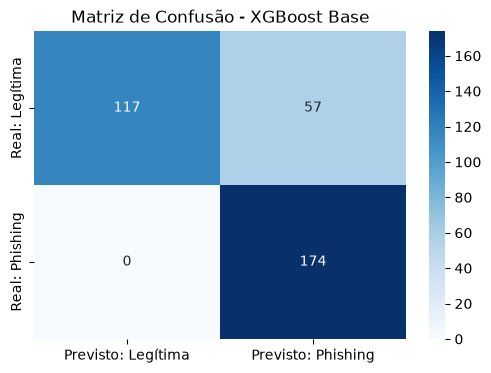

In [14]:
df_dados = df_feats[colunas_do_treinamento]
previsoes = models_df_35['xgboost_base'].predict(df_dados)
previsoes_corrigidas = 1 - previsoes
df_dados['Previsao_Modelo'] = previsoes_corrigidas
df_dados['URL'] = df_dados.index
df_final = pd.merge(df, df_dados[['URL', 'Previsao_Modelo']], on='URL', how='left')
y_verdadeiro = df_final['Label']
y_previsto = df_final['Previsao_Modelo']

print(classification_report(
    y_verdadeiro, 
    y_previsto, 
    target_names=['Legítima (0)', 'Phishing (1)'],
    digits=4
))

matriz = confusion_matrix(y_verdadeiro, y_previsto)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: Legítima', 'Previsto: Phishing'],
            yticklabels=['Real: Legítima', 'Real: Phishing'])
plt.title('Matriz de Confusão - XGBoost Base')
plt.show()

              precision    recall  f1-score   support

Legítima (0)     1.0000    0.6552    0.7917       174
Phishing (1)     0.7436    1.0000    0.8529       174

    accuracy                         0.8276       348
   macro avg     0.8718    0.8276    0.8223       348
weighted avg     0.8718    0.8276    0.8223       348



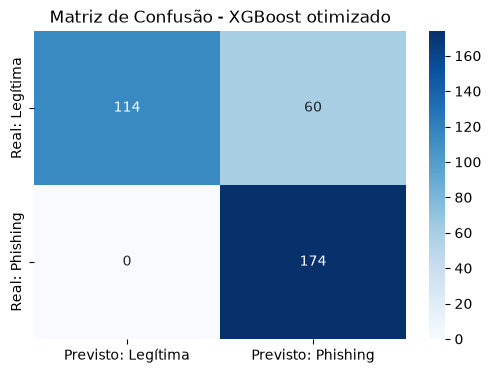

In [15]:
df_dados = df_feats[colunas_do_treinamento]
previsoes = models_df_35['xgboost_otimizado'].predict(df_dados)
previsoes_corrigidas = 1 - previsoes
df_dados['Previsao_Modelo'] = previsoes_corrigidas
df_dados['URL'] = df_dados.index
df_final = pd.merge(df, df_dados[['URL', 'Previsao_Modelo']], on='URL', how='left')
y_verdadeiro = df_final['Label']
y_previsto = df_final['Previsao_Modelo']

print(classification_report(
    y_verdadeiro, 
    y_previsto, 
    target_names=['Legítima (0)', 'Phishing (1)'],
    digits=4
))

matriz = confusion_matrix(y_verdadeiro, y_previsto)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: Legítima', 'Previsto: Phishing'],
            yticklabels=['Real: Legítima', 'Real: Phishing'])
plt.title('Matriz de Confusão - XGBoost otimizado')
plt.show()